# Notebook 08 — Model Validation

**Project**: ML-Based QSAR Modeling for Anti-Leishmanial Sulfonamide Derivatives
**Input**: Trained models (RF, SVM, XGB, LGBM, Stacking), selected features, test set
**Output**:
- `results/model_metrics/test_set_full_metrics.csv` — Comprehensive test-set metrics
- `results/model_metrics/y_randomization.csv` — Y-randomization results (50 iterations)
- `figures/roc_curves.png` — ROC curves for all models
- `figures/williams_plot.png` — Applicability domain (Williams plot)

**Validation Protocol**:
1. External test set evaluation (full metrics for all models)
2. Y-randomization test (50 label-scramble iterations)
3. Williams plot — applicability domain assessment
4. ROC curve comparison

**QC-8**: Y-randomization gap > 3 std deviations; test MCC > 0.30

---


In [1]:
# ============================================================
# CELL 1: Imports and Configuration
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings, sys, joblib
from datetime import datetime
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, matthews_corrcoef,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
DATA = PROJECT_ROOT / 'data' / 'processed'
MODELS = PROJECT_ROOT / 'models'
RESULTS = PROJECT_ROOT / 'results' / 'model_metrics'
FIGURES = PROJECT_ROOT / 'figures'

for d in [RESULTS, FIGURES]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M')}")


Project root: e:\PhD_Projecttttttttttttt\PhD_QSAR_Leishmania
Timestamp: 2026-05-22 14:21


In [2]:
# ============================================================
# CELL 2: Load Data and Models
# ============================================================

X_train = pd.read_csv(DATA / 'X_train_selected.csv', index_col=0)
X_test  = pd.read_csv(DATA / 'X_test_selected.csv',  index_col=0)
y_train_df = pd.read_csv(DATA / 'y_train.csv', index_col=0)
y_test_df  = pd.read_csv(DATA / 'y_test.csv',  index_col=0)

common_tr = X_train.index.intersection(y_train_df.index)
common_te = X_test.index.intersection(y_test_df.index)
X_train = X_train.loc[common_tr]
X_test  = X_test.loc[common_te]
y_train = (y_train_df.loc[common_tr, 'activity_class'] == 'Active').astype(int)
y_test  = (y_test_df.loc[common_te,  'activity_class'] == 'Active').astype(int)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} (Active={y_train.sum()})  |  y_test: {y_test.shape} (Active={y_test.sum()})")

# Load models
rf   = joblib.load(MODELS / 'rf_classifier.joblib')
svm  = joblib.load(MODELS / 'svm_classifier.joblib')
xgb  = joblib.load(MODELS / 'xgb_classifier.joblib')
lgbm = joblib.load(MODELS / 'lgbm_classifier.joblib')

models = {'RF': rf, 'SVM': svm, 'XGBoost': xgb, 'LightGBM': lgbm}

# Rebuild stacking meta-model predictions
meta_model = joblib.load(MODELS / 'stacking_meta_model.joblib')
test_probs = {name: m.predict_proba(X_test)[:, 1] for name, m in models.items()}
meta_test = pd.DataFrame(test_probs)
stack_pred = meta_model.predict(meta_test)
stack_prob = meta_model.predict_proba(meta_test)[:, 1]

# Consensus
cons_preds = np.array([m.predict(X_test) for m in models.values()])
cons_pred = (cons_preds.sum(axis=0) >= 3).astype(int)
cons_prob = np.array([m.predict_proba(X_test)[:, 1] for m in models.values()]).mean(axis=0)

print(f"\nLoaded {len(models)} base models + stacking meta-model + consensus")


X_train: (8627, 1163)  |  X_test: (4068, 1163)
y_train: (8627,) (Active=4650)  |  y_test: (4068,) (Active=2188)



Loaded 4 base models + stacking meta-model + consensus


## Part A — External Test Set Evaluation

Comprehensive metrics on the held-out test set for all models including ensemble methods.


In [3]:
# ============================================================
# CELL 3: External Test Set — Full Metrics
# ============================================================

def evaluate_model(y_true, y_pred, y_prob, name):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Balanced_Accuracy': balanced_accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'MCC': matthews_corrcoef(y_true, y_pred),
        'ROC_AUC': roc_auc_score(y_true, y_prob),
    }

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results.append(evaluate_model(y_test, y_pred, y_prob, name))

# Consensus
results.append(evaluate_model(y_test, cons_pred, cons_prob, 'Consensus (>=3/4)'))

# Stacking
results.append(evaluate_model(y_test, stack_pred, stack_prob, 'Stacking (LR meta)'))

results_df = pd.DataFrame(results)
results_df.to_csv(RESULTS / 'test_set_full_metrics.csv', index=False)

print("=== External Test Set — Full Metrics ===")
print(results_df.round(4).to_string(index=False))
print(f"\nSaved: results/model_metrics/test_set_full_metrics.csv")

# Classification report for best model
best_name = results_df.loc[results_df['Balanced_Accuracy'].idxmax(), 'Model']
print(f"\n--- Classification Report: {best_name} ---")
if 'Stacking' in best_name:
    print(classification_report(y_test, stack_pred, target_names=['Inactive', 'Active']))
elif 'Consensus' in best_name:
    print(classification_report(y_test, cons_pred, target_names=['Inactive', 'Active']))
else:
    best_model = models[best_name]
    print(classification_report(y_test, best_model.predict(X_test), target_names=['Inactive', 'Active']))


=== External Test Set — Full Metrics ===
             Model  Accuracy  Balanced_Accuracy  Precision  Recall     F1    MCC  ROC_AUC
                RF    0.7534             0.7544     0.7875  0.7418 0.7639 0.5074   0.8336
               SVM    0.7584             0.7559     0.7684  0.7884 0.7783 0.5131   0.7982
           XGBoost    0.7559             0.7547     0.7745  0.7706 0.7725 0.5092   0.8292
          LightGBM    0.7576             0.7556     0.7705  0.7824 0.7764 0.5119   0.8248
 Consensus (>=3/4)    0.7574             0.7573     0.7834  0.7587 0.7708 0.5135   0.8298
Stacking (LR meta)    0.7623             0.7603     0.7746  0.7870 0.7808 0.5213   0.8328

Saved: results/model_metrics/test_set_full_metrics.csv

--- Classification Report: Stacking (LR meta) ---
              precision    recall  f1-score   support

    Inactive       0.75      0.73      0.74      1880
      Active       0.77      0.79      0.78      2188

    accuracy                           0.76      4068
   m

## Part B — Y-Randomization Test

Scramble activity labels 50 times and retrain RF. If the real model is significantly better
than all randomized models (> 3 std deviations above mean), the model learned real patterns.


In [4]:
# ============================================================
# CELL 4: Y-Randomization Test (50 iterations)
# ============================================================

N_RANDOM = 50

print(f"Running Y-randomization ({N_RANDOM} iterations)...")
print("  Each iteration: scramble labels -> train RF -> evaluate on test set")
print("  This validates that the model learned real structure-activity patterns.\n")

random_scores = []
rng = np.random.RandomState(SEED)

for i in range(N_RANDOM):
    y_shuffled = y_train.copy()
    y_shuffled = y_shuffled.sample(frac=1, random_state=rng.randint(0, 100000)).values

    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=SEED)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1))
    ])
    pipe.fit(X_train, y_shuffled)

    y_pred_rand = pipe.predict(X_test)
    ba_rand = balanced_accuracy_score(y_test, y_pred_rand)
    random_scores.append(ba_rand)

    if (i + 1) % 10 == 0:
        print(f"  Iteration {i+1}/{N_RANDOM}: BA={ba_rand:.4f}")

random_scores = np.array(random_scores)

# Real model performance (RF)
real_ba = balanced_accuracy_score(y_test, rf.predict(X_test))

# Statistics
rand_mean = random_scores.mean()
rand_std  = random_scores.std()
z_score   = (real_ba - rand_mean) / rand_std if rand_std > 0 else float('inf')
gap_std   = z_score

print(f"\n{'='*55}")
print(f"Y-Randomization Results")
print(f"{'='*55}")
print(f"  Real RF BA            : {real_ba:.4f}")
print(f"  Random mean BA        : {rand_mean:.4f} +/- {rand_std:.4f}")
print(f"  Random max BA         : {random_scores.max():.4f}")
print(f"  Random min BA         : {random_scores.min():.4f}")
print(f"  Gap (z-score)         : {z_score:.1f} std deviations")
print(f"  Real > all random?    : {real_ba > random_scores.max()}")
print(f"{'='*55}")

if z_score > 3:
    print(f"  [PASS] Model is {z_score:.1f} std above random (threshold: 3.0)")
else:
    print(f"  [WARNING] Gap is only {z_score:.1f} std (threshold: 3.0)")

# Save
y_rand_df = pd.DataFrame({
    'iteration': range(1, N_RANDOM + 1),
    'random_BA': random_scores
})
y_rand_df.loc[len(y_rand_df)] = {'iteration': 'real_model', 'random_BA': real_ba}
y_rand_df.to_csv(RESULTS / 'y_randomization.csv', index=False)
print(f"\nSaved: results/model_metrics/y_randomization.csv")


Running Y-randomization (50 iterations)...
  Each iteration: scramble labels -> train RF -> evaluate on test set
  This validates that the model learned real structure-activity patterns.



  Iteration 10/50: BA=0.5094


  Iteration 20/50: BA=0.4999


  Iteration 30/50: BA=0.5266


  Iteration 40/50: BA=0.5084


  Iteration 50/50: BA=0.4865

Y-Randomization Results
  Real RF BA            : 0.7544
  Random mean BA        : 0.4995 +/- 0.0114
  Random max BA         : 0.5266
  Random min BA         : 0.4739
  Gap (z-score)         : 22.3 std deviations
  Real > all random?    : True
  [PASS] Model is 22.3 std above random (threshold: 3.0)

Saved: results/model_metrics/y_randomization.csv


## Part C — ROC Curves (All Models)

Receiver Operating Characteristic curves comparing all models on the test set.


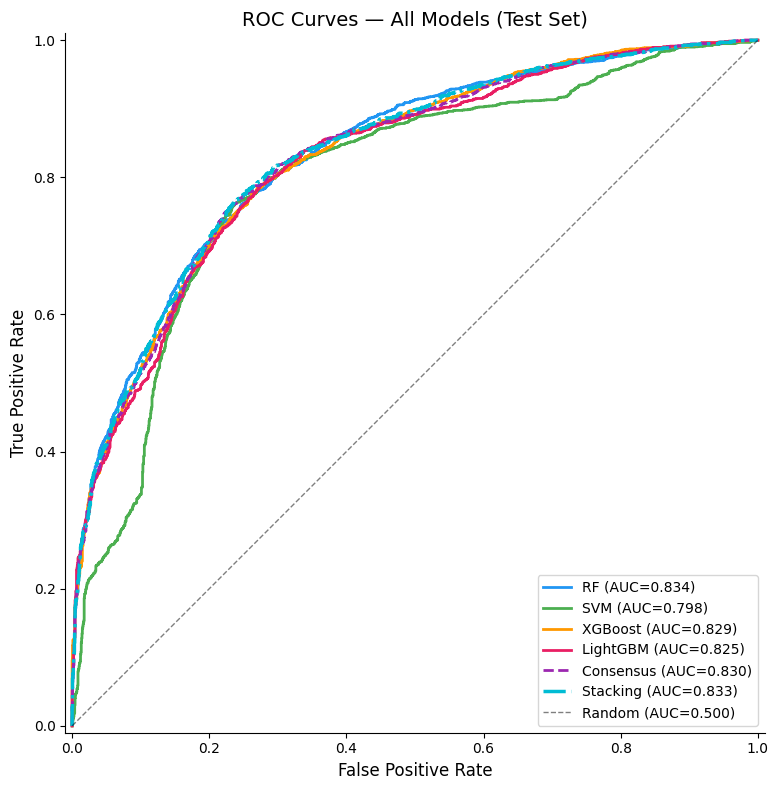

Figure saved: figures/roc_curves.png


In [5]:
# ============================================================
# CELL 5: ROC Curves — All Models
# ============================================================

fig, ax = plt.subplots(figsize=(8, 8))

colors = {'RF': '#2196F3', 'SVM': '#4CAF50', 'XGBoost': '#FF9800',
          'LightGBM': '#E91E63', 'Consensus': '#9C27B0', 'Stacking': '#00BCD4'}

# Individual models
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', color=colors[name], linewidth=2)

# Consensus
fpr, tpr, _ = roc_curve(y_test, cons_prob)
auc_val = roc_auc_score(y_test, cons_prob)
ax.plot(fpr, tpr, label=f'Consensus (AUC={auc_val:.3f})', color=colors['Consensus'],
        linewidth=2, linestyle='--')

# Stacking
fpr, tpr, _ = roc_curve(y_test, stack_prob)
auc_val = roc_auc_score(y_test, stack_prob)
ax.plot(fpr, tpr, label=f'Stacking (AUC={auc_val:.3f})', color=colors['Stacking'],
        linewidth=2.5, linestyle='-.')

# Reference line
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC=0.500)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models (Test Set)', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.set_aspect('equal')
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(FIGURES / 'roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: figures/roc_curves.png")


## Part D — Applicability Domain (Williams Plot)

The Williams plot identifies test compounds outside the model's applicability domain by comparing:
- **Leverage (h_i)**: How far a compound is from the training centroid in feature space
- **Standardized residuals**: How much the prediction deviates from reality

Compounds with high leverage AND large residuals are unreliable predictions.


Number of features (p)  : 1163
Training set size (n)   : 8627
Critical leverage (h*)  : 0.4044

Compounds with h > h*   : 129 (3.2%)
Compounds with |r| > 3  : 0
Outside AD (both)       : 0 (0.0%)
Inside AD               : 4068 (100.0%)


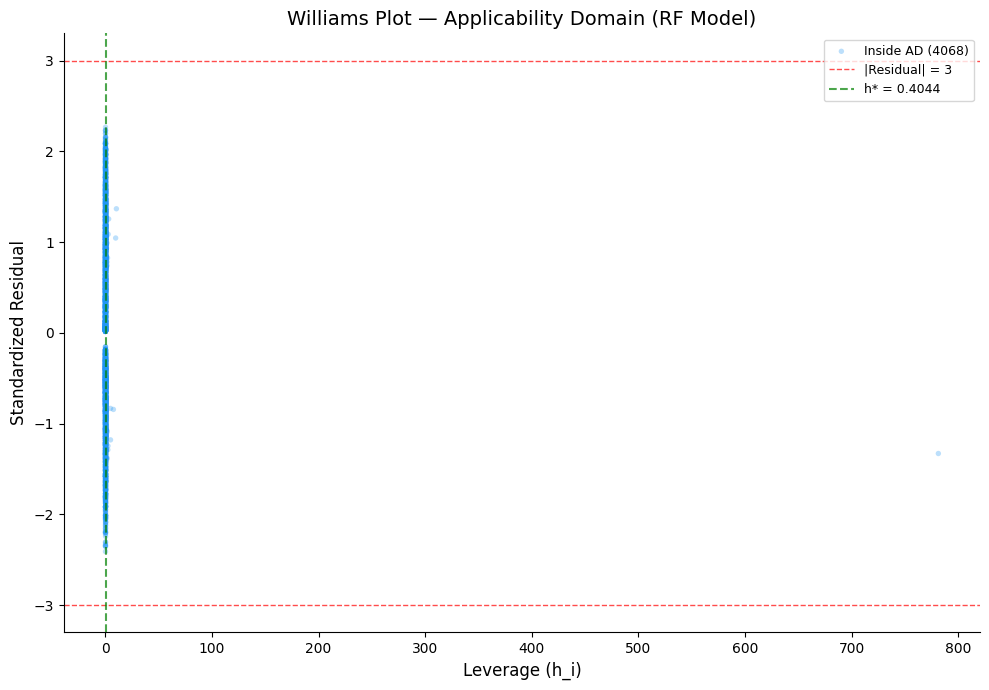

Figure saved: figures/williams_plot.png


In [6]:
# ============================================================
# CELL 6: Williams Plot — Applicability Domain
# ============================================================

# Use the best single model (RF) for Williams plot
y_prob_train = rf.predict_proba(X_train)[:, 1]
y_prob_test  = rf.predict_proba(X_test)[:, 1]

# --- Leverage calculation ---
# Hat matrix: H = X (X'X)^(-1) X'
X_tr_np = X_train.values.astype(float)
X_te_np = X_test.values.astype(float)

# Regularized pseudo-inverse for numerical stability
XtX = X_tr_np.T @ X_tr_np
reg = 1e-6 * np.eye(XtX.shape[0])
XtX_inv = np.linalg.inv(XtX + reg)

# Leverage for test set
h_test = np.array([x @ XtX_inv @ x.T for x in X_te_np])

# Critical leverage: h* = 3p/n
n_train = X_tr_np.shape[0]
p = X_tr_np.shape[1]
h_star = 3 * p / n_train

print(f"Number of features (p)  : {p}")
print(f"Training set size (n)   : {n_train}")
print(f"Critical leverage (h*)  : {h_star:.4f}")

# --- Standardized residuals ---
residuals = y_test.values - y_prob_test
std_res = residuals / (residuals.std() + 1e-10)

# --- Identify compounds outside AD ---
outside_leverage = h_test > h_star
outside_residual = np.abs(std_res) > 3
outside_ad = outside_leverage & outside_residual
inside_ad = ~outside_ad

n_outside = outside_ad.sum()
pct_outside = n_outside / len(y_test) * 100
n_high_leverage = outside_leverage.sum()

print(f"\nCompounds with h > h*   : {n_high_leverage} ({n_high_leverage/len(y_test)*100:.1f}%)")
print(f"Compounds with |r| > 3  : {(np.abs(std_res)>3).sum()}")
print(f"Outside AD (both)       : {n_outside} ({pct_outside:.1f}%)")
print(f"Inside AD               : {inside_ad.sum()} ({inside_ad.sum()/len(y_test)*100:.1f}%)")

# --- Williams Plot ---
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(h_test[inside_ad], std_res[inside_ad],
           c='#2196F3', alpha=0.3, s=15, label=f'Inside AD ({inside_ad.sum()})', edgecolors='none')

if n_outside > 0:
    ax.scatter(h_test[outside_ad], std_res[outside_ad],
               c='#F44336', alpha=0.8, s=30, marker='x', linewidths=1.5,
               label=f'Outside AD ({n_outside})')

# Thresholds
ax.axhline(y=3,  color='red', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(y=-3, color='red', linestyle='--', linewidth=1, alpha=0.7, label='|Residual| = 3')
ax.axvline(x=h_star, color='green', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'h* = {h_star:.4f}')

ax.set_xlabel('Leverage (h_i)', fontsize=12)
ax.set_ylabel('Standardized Residual', fontsize=12)
ax.set_title('Williams Plot — Applicability Domain (RF Model)', fontsize=14)
ax.legend(loc='upper right', fontsize=9)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(FIGURES / 'williams_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: figures/williams_plot.png")


## Part E — Y-Randomization Distribution Plot

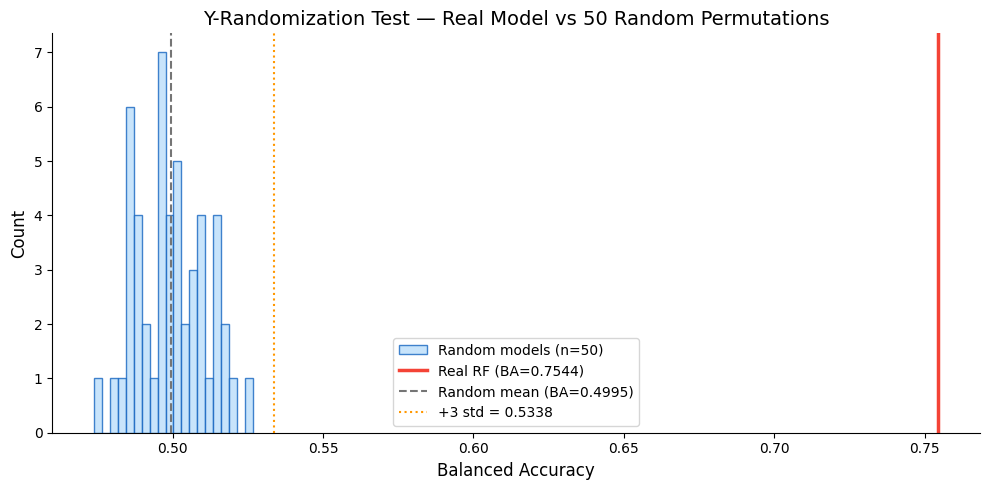

Figure saved: figures/y_randomization.png


In [7]:
# ============================================================
# CELL 7: Y-Randomization Distribution Plot
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(random_scores, bins=20, color='#BBDEFB', edgecolor='#1565C0',
        alpha=0.8, label=f'Random models (n={N_RANDOM})')
ax.axvline(x=real_ba, color='#F44336', linewidth=2.5, linestyle='-',
           label=f'Real RF (BA={real_ba:.4f})')
ax.axvline(x=rand_mean, color='#757575', linewidth=1.5, linestyle='--',
           label=f'Random mean (BA={rand_mean:.4f})')
ax.axvline(x=rand_mean + 3*rand_std, color='#FF9800', linewidth=1.5, linestyle=':',
           label=f'+3 std = {rand_mean + 3*rand_std:.4f}')

ax.set_xlabel('Balanced Accuracy', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(f'Y-Randomization Test — Real Model vs {N_RANDOM} Random Permutations', fontsize=14)
ax.legend(fontsize=10)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(FIGURES / 'y_randomization.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: figures/y_randomization.png")


## Quality Control Checkpoint

In [8]:
# ============================================================
# CELL 8: QC-8 — Validation Audit
# ============================================================

print("=" * 60)
print("QUALITY CONTROL CHECKPOINT QC-8: Model Validation")
print("=" * 60)

checks = {}

# Check 1: Y-randomization gap
checks[f'Y-randomization gap > 3 std (actual: {gap_std:.1f})'] = gap_std > 3

# Check 2: Real BA > all random BAs
checks[f'Real BA ({real_ba:.4f}) > max random BA ({random_scores.max():.4f})'] = real_ba > random_scores.max()

# Check 3: Best test MCC > 0.30
best_mcc = results_df['MCC'].max()
checks[f'Best test MCC > 0.30 (actual: {best_mcc:.3f})'] = best_mcc > 0.30

# Check 4: Best test AUC > 0.80
best_auc = results_df['ROC_AUC'].max()
checks[f'Best test AUC > 0.80 (actual: {best_auc:.3f})'] = best_auc > 0.80

# Check 5: AD coverage > 90%
ad_coverage = inside_ad.sum() / len(y_test) * 100
checks[f'AD coverage > 90% (actual: {ad_coverage:.1f}%)'] = ad_coverage > 90

all_pass = True
for check, passed in checks.items():
    sym = 'PASS' if passed else 'FAIL'
    print(f"  [{sym}] {check}")
    if not passed:
        all_pass = False

print("=" * 60)
if all_pass:
    print("QC-8 PASSED — Model validation complete")
else:
    print("QC-8: Some checks need review")

print(f"\nValidation Summary:")
print(f"  Best model (test BA)  : {results_df.loc[results_df['Balanced_Accuracy'].idxmax(), 'Model']}")
print(f"  Y-randomization       : {gap_std:.1f} std above random")
print(f"  AD coverage           : {ad_coverage:.1f}%")
print(f"  Figures saved         : roc_curves.png, williams_plot.png, y_randomization.png")
print("=" * 60)


QUALITY CONTROL CHECKPOINT QC-8: Model Validation
  [PASS] Y-randomization gap > 3 std (actual: 22.3)
  [PASS] Real BA (0.7544) > max random BA (0.5266)
  [PASS] Best test MCC > 0.30 (actual: 0.521)
  [PASS] Best test AUC > 0.80 (actual: 0.834)
  [PASS] AD coverage > 90% (actual: 100.0%)
QC-8 PASSED — Model validation complete

Validation Summary:
  Best model (test BA)  : Stacking (LR meta)
  Y-randomization       : 22.3 std above random
  AD coverage           : 100.0%
  Figures saved         : roc_curves.png, williams_plot.png, y_randomization.png
